In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras import optimizers
from keras.layers import LSTM
from keras.layers import Dense, Reshape
from keras.models import Sequential
import math
import sys
sys.path.insert(0, '..')
from lstm import AVERT_LSTM

processed_dpath = '../processed_data/'

### Basic usage example

/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)


Performing Training...
Epoch 1/2


/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2298/2298 - 54s - 24ms/step - loss: 0.0163 - val_loss: 0.0199
Epoch 2/2
2298/2298 - 54s - 23ms/step - loss: 0.0156 - val_loss: 0.0190
...Training Done!


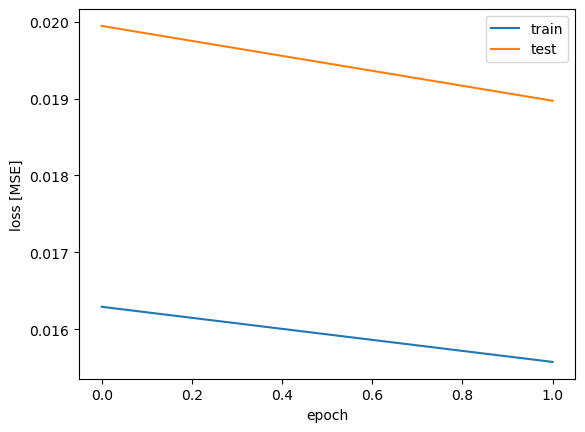

6030/6030 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


In [22]:
# usage

# read in dataInterpolated.csv
df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)

# define variables for LSTM
lstm_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size'] 

# define and fit the model
lstm = AVERT_LSTM(df, lstm_vars=lstm_vars)
lstm.CreateModel(n_past=3, n_future=2, n_epochs=2)
lstm.Fit()

# predict using the model
lstm.Predict()

# original DataFrame
dataOrig = lstm.df

# predicted DataFrame
dataPred = lstm.df_pred

### Alex sandbox

/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)
/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:200: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=10)


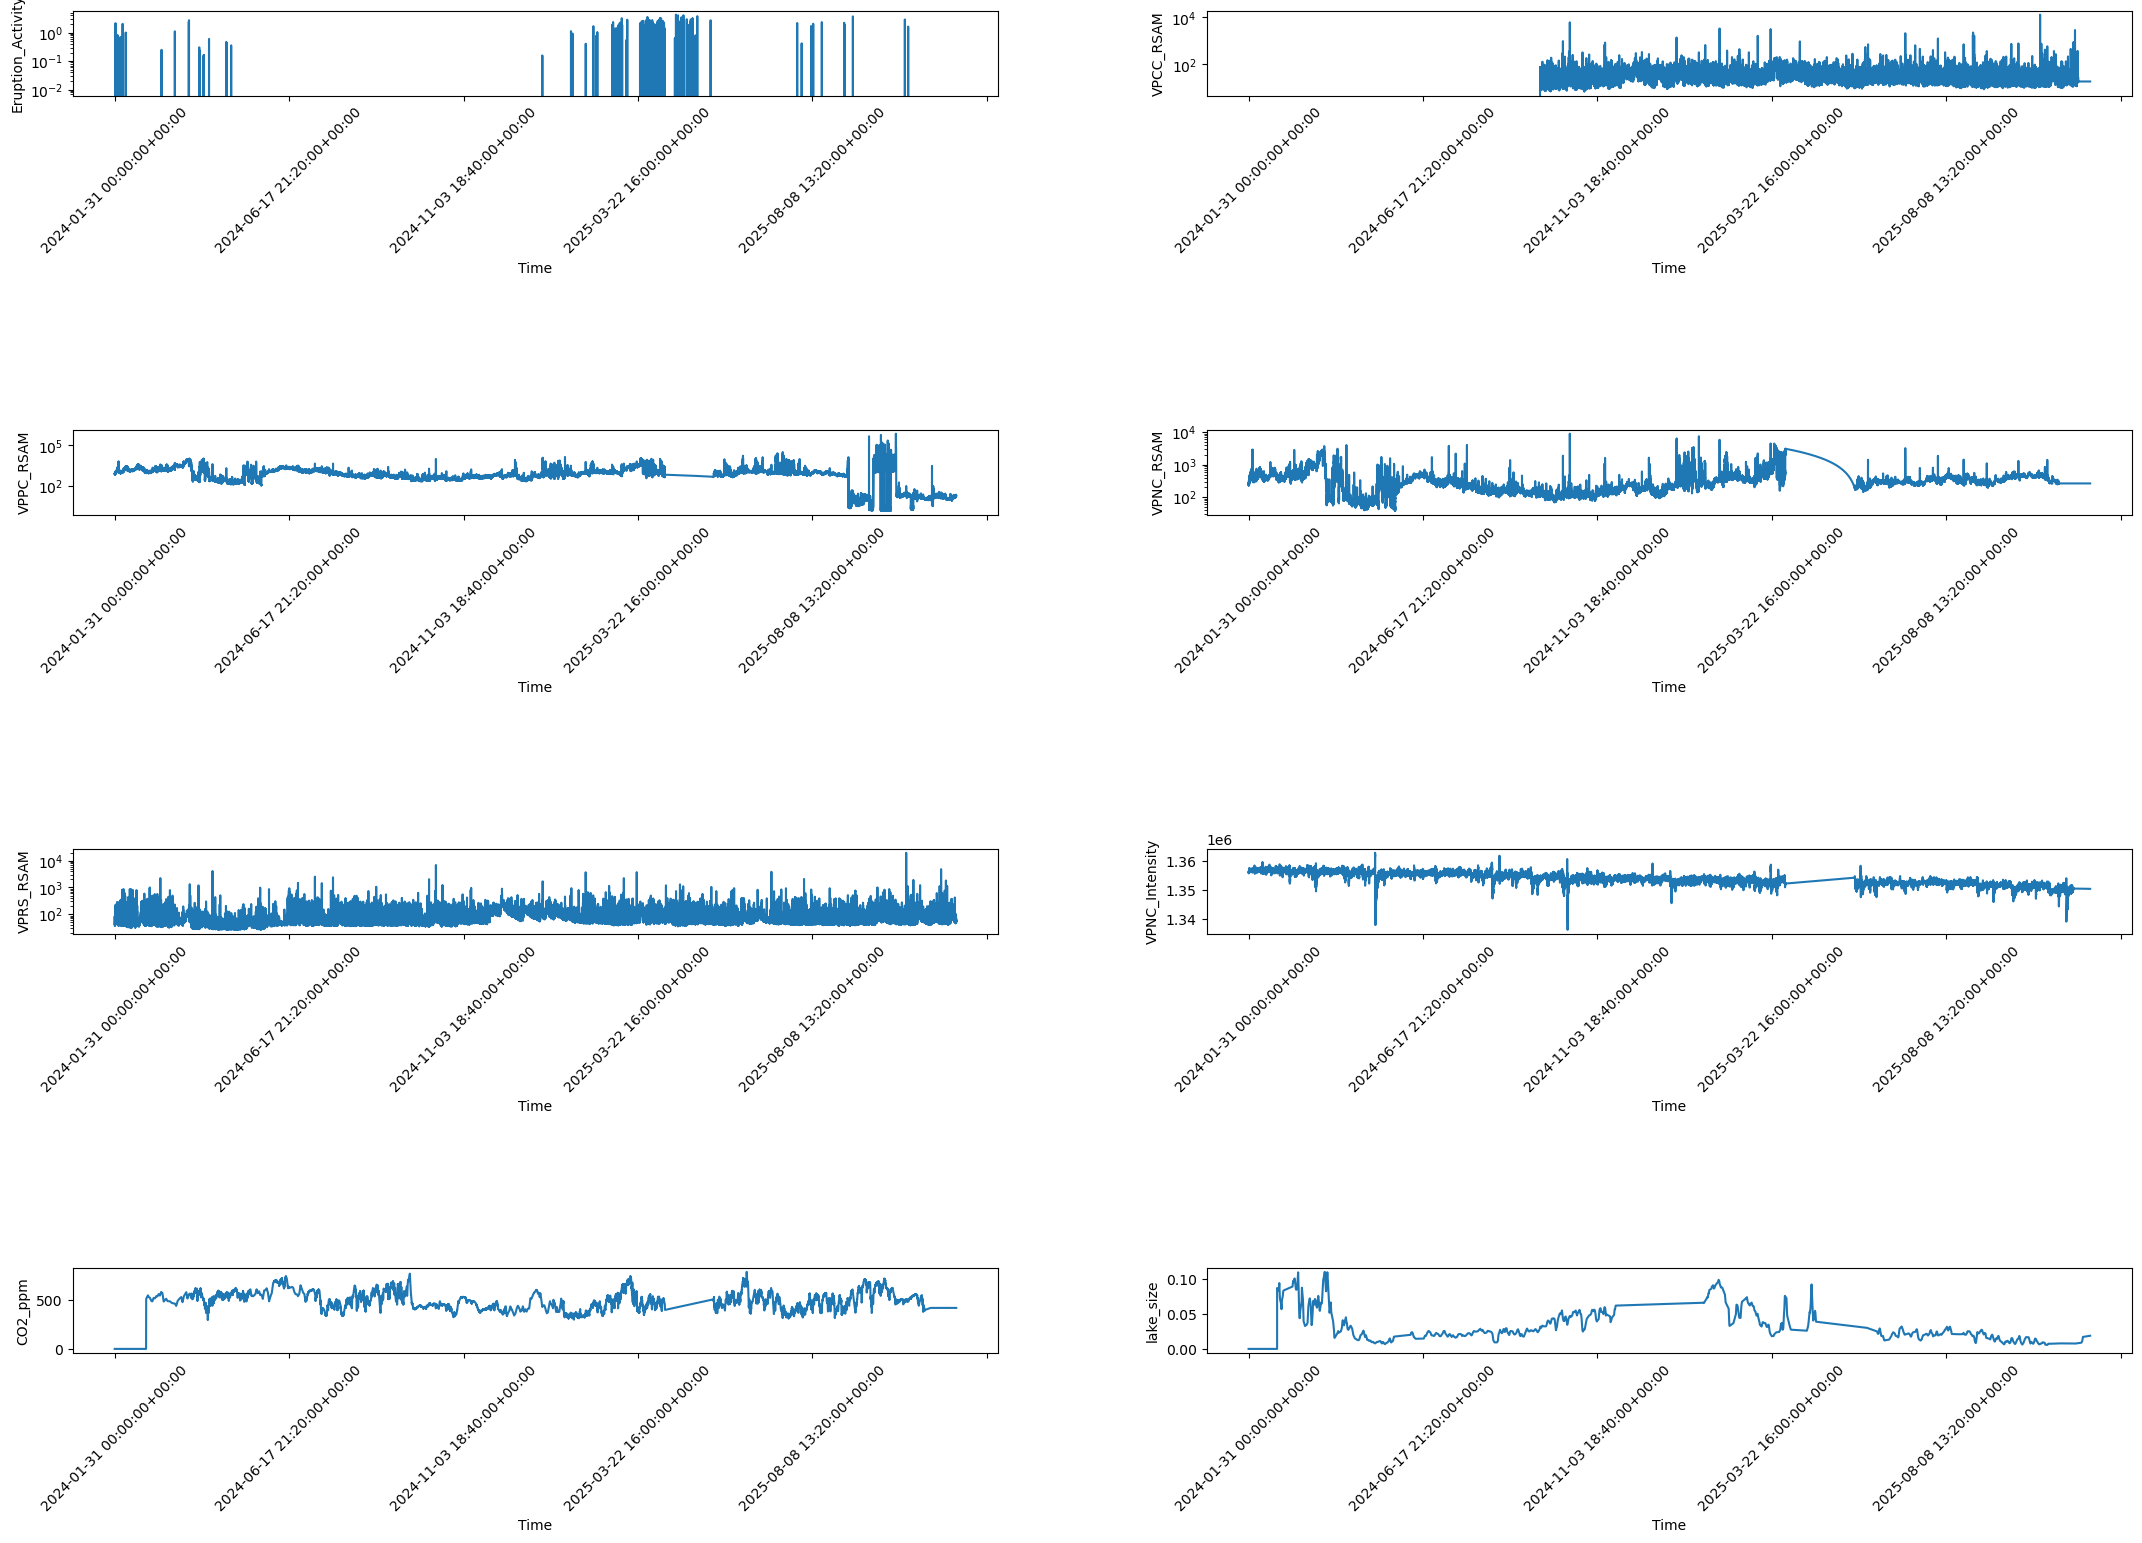

In [2]:
df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
lstm_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size'] 

# define model and plot data
lstm = AVERT_LSTM(df, lstm_vars=lstm_vars)
lstm.CreateModel(n_past=3, n_future=2, n_epochs=2)
lstm.PlotData()